# Лабораторная работа 4
## Полносвязная сеть (бинарный классификатор) своими руками на CPU
**Выполнил:** Тоц Леонид Александрович<br>
**Группа:** ИВТ-2<br>
**Дисциплина:** Базовая математика для искусственного интеллекта

Цель: реализовать MLP, прямой проход и backpropagation на NumPy, обучить сеть
mini-batches и оценить классификацию на независимом test. Готовые нейросетевые
модели и автоматическое дифференцирование не используются.

Выбран один из разрешённых датасетов: **Banknote Authentication**,
[UCI](https://archive.ics.uci.edu/dataset/267/banknote+authentication),
DOI: 10.24432/C55P57, Volker Lohweg, 2012, лицензия CC BY 4.0.
4 числовых признака: variance, skewness, curtosis, entropy; цель class ∈ {0, 1}.
Класс 1 считаем положительным без переименования исходных меток.

Открывайте ноутбук в папке lab4 вместе с mlp.py, experiment.py и data/.
В Google Colab первая ячейка автоматически загрузит код и данные из GitHub.
Все ячейки выполнены; для повторения выберите Run All.

In [1]:
from pathlib import Path
import os
import sys
import subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repository = Path('/content/Basic_Mathematics_for_Artificial_Intelligence')
    if not repository.exists():
        subprocess.run(['git', 'clone', '--depth', '1', '--branch', 'main',
                        'https://github.com/huksleva/Basic_Mathematics_for_Artificial_Intelligence.git',
                        str(repository)], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                    str(repository / 'lab4/requirements.txt')], check=True)
    os.chdir(repository / 'lab4')

ROOT = Path.cwd()
if not (ROOT / 'mlp.py').exists():
    ROOT = ROOT / 'lab4'
if not (ROOT / 'mlp.py').exists():
    raise FileNotFoundError('Откройте ноутбук в папке lab4 вместе с кодом и данными')
sys.path.insert(0, str(ROOT))

import json
import inspect
import numpy as np
import pandas as pd
from IPython.display import display, Image, Code
from mlp import (MLP, Standardizer, load_dataset, stratified_split,
                 gradient_check, select_threshold, classification_metrics)
from experiment import CONFIG, run_experiment

print('Автор: Тоц Леонид Александрович, ИВТ-2')
print('NumPy:', np.__version__, '| pandas:', pd.__version__, '| устройство: CPU')

Автор: Тоц Леонид Александрович, ИВТ-2
NumPy: 2.5.1 | pandas: 3.0.6 | устройство: CPU


## 1. Данные, повторы и разделение
В исходном файле 1372 записи, пропусков нет. Полные дубликаты удаляем **до**
разбиения, иначе один и тот же объект может попасть в train и test.
Стратифицированное разбиение около 60/20/20 сохраняет доли классов.
Seed фиксирован; индексы исходных строк сохраняются в artifacts/split.csv.

In [2]:
x, y, source_rows, audit = load_dataset(ROOT / 'data/data_banknote_authentication.txt')
split = stratified_split(y, seed=CONFIG['split_seed'])
display(pd.Series(audit, name='Аудит данных'))
display(pd.DataFrame([
    {'split': name, 'rows': len(idx), 'class_0': int((y[idx]==0).sum()),
     'class_1': int((y[idx]==1).sum()), 'fraction': len(idx)/len(y)}
    for name, idx in split.items()
]))
assert len(np.unique(np.concatenate(list(split.values())))) == len(y)
assert len(np.unique(x, axis=0)) == len(x)
print('OK: дубликаты удалены, части не пересекаются')

raw_rows                    1372
unique_rows                 1348
removed_duplicates            24
features                       4
raw_class_counts      [762, 610]
class_counts          [738, 610]
missing_values                 0
Name: Аудит данных, dtype: object

,split,rows,class_0,class_1,fraction
0,train,809,443,366,0.600148
1,val,270,148,122,0.200297
2,test,269,147,122,0.199555


OK: дубликаты удалены, части не пересекаются


## 2. Стандартизация без утечки
Для каждого признака $x'_j=(x_j-\mu_j)/s_j$.
Среднее и стандартное отклонение (ddof=0) вычисляем **только на train**.
На val/test применяем те же параметры; постоянный признак получает scale=1.

In [3]:
scaler = Standardizer().fit(x[split['train']])
scaled = {name: scaler.transform(x[idx]) for name, idx in split.items()}
display(pd.DataFrame({'feature': ['variance','skewness','curtosis','entropy'],
                      'train_mean': scaler.mean_, 'train_std': scaler.scale_}))
np.testing.assert_allclose(scaled['train'].mean(axis=0), 0, atol=1e-12)
np.testing.assert_allclose(scaled['train'].std(axis=0), 1, atol=1e-12)
print('OK: стандартизация train проверена')

,feature,train_mean,train_std
0,variance,0.476340,2.900210
1,skewness,1.923848,5.848658
2,curtosis,1.378593,4.260203
3,entropy,-1.120953,2.105808


OK: стандартизация train проверена


## 3. Математика и реализация MLP
Объекты лежат **по строкам**. Для слоя $l$:

$$Z_l=A_{l-1}W_l+b_l,\quad A_l=\mathrm{ReLU}(Z_l),\quad
\hat p=\sigma(Z_L).$$

$$J=\frac1m\sum_i[\log(1+e^{z_i})-y_i z_i]
 +\frac{\lambda}{2}\sum_l\|W_l\|_F^2.$$

BCE вычисляется устойчиво через np.logaddexp. L2 применяется только к весам.
Выходная ошибка $D_L=(\hat p-y)/m$; скрытая ошибка
$D_l=(D_{l+1}W_{l+1}^T)\odot f'(Z_l)$.

$$\nabla W_l=A_{l-1}^TD_l+\lambda W_l,\quad
\nabla b_l=\sum_iD_{l,i}.$$

Усреднение по **фактическому** размеру mini-batch выполняется один раз.
Все градиенты вычисляются до изменения весов. Ниже приведён реальный код
обратного прохода из mlp.py; остальные методы доступны в том же модуле.

In [4]:
display(Code(inspect.getsource(MLP.loss_and_gradients), language='python'))
model_preview = MLP(CONFIG['layer_sizes'], CONFIG['activation'], CONFIG['l2'], CONFIG['model_seed'])
print('Архитектура:', model_preview.layer_sizes)
print('Формы W:', [w.shape for w in model_preview.weights])
print('Параметров:', sum(w.size+b.size for w,b in zip(model_preview.weights, model_preview.biases)))

def loss_and_gradients(self, x: np.ndarray, y: np.ndarray) -> tuple[float, list, list]:
        a, z = self.forward(x)
        target = np.asarray(y).reshape(-1, 1)
        m = len(target)  # реальный размер, включая последний неполный mini-batch
        delta = (a[-1] - target) / m
        dw, db = [None] * len(self.weights), [None] * len(self.weights)
        for layer in reversed(range(len(self.weights))):
            dw[layer] = a[layer].T @ delta + self.l2 * self.weights[layer]
            db[layer] = delta.sum(axis=0, keepdims=True)
            if layer > 0:
                derivative = (z[layer - 1] > 0) if self.activation == "relu" else 1 - a[layer] ** 2
                delta = (delta @ self.weights[layer].T) * derivative
        objective = float(np.mean(np.logaddexp(0, z[-1]) - target * z[-1]))
        objective += self.l2 / 2 * sum(float(np.sum(w * w)) for w in self.weights)
        return objective, dw, db

Архитектура: (4, 32, 16, 1)
Формы W: [(4, 32), (32, 16), (16, 1)]
Параметров: 705


## 4. Численная проверка backpropagation
Для каждого из 47 параметров маленькой сети 4→5→3→1 сравниваем ручной градиент
с центральной разностью $[J(\theta+\varepsilon)-J(\theta-\varepsilon)]/(2\varepsilon)$,
где $\varepsilon=10^{-6}$. Проверяем ReLU и tanh с L2=0.07.
Смещения ненулевые: проверка ReLU должна проводиться вдали от недифференцируемой точки $z=0$.

In [5]:
checks = {}
for activation in ['relu', 'tanh']:
    tiny = MLP((4,5,3,1), activation=activation, l2=.07, seed=12)
    rng = np.random.default_rng(123)
    tiny.biases = [rng.uniform(.2,.5,b.shape) for b in tiny.biases]
    checks[activation] = gradient_check(tiny, scaled['train'][:7], y[split['train']][:7])
    assert checks[activation]['relative_l2_error'] < 1e-6
display(pd.DataFrame(checks).T)
print('OK: ручные градиенты совпадают с численными')

,parameters_checked,max_absolute_error,relative_l2_error
relu,47.0,1.485251e-10,6.332574e-10
tanh,47.0,1.169279e-10,6.148637e-10


OK: ручные градиенты совпадают с численными


## 5. Протокол эксперимента и обучение
Архитектура 4→32→16→1, ReLU в скрытых слоях и сигмоида на выходе.
Инициализация He для скрытых ReLU, Xavier для выходных логитов; bias=0.
SGD с моментом: $v\leftarrow\beta v+g$, $\theta\leftarrow\theta-\eta v$.
Максимум 150 эпох, batch=32, lr=0.03, momentum=0.9, L2=0.0001.
Ранняя остановка: patience=20, min_delta=0.00001 по val BCE;
восстанавливается абсолютный минимум val BCE, даже если обучение дошло до лимита.

После каждой эпохи история сохраняется в pandas.DataFrame:
epoch, loss, val_loss, accuracy, val_accuracy, objective.
loss/val_loss - чистая BCE; objective - train BCE + L2.
Accuracy в истории использует фиксированный порог 0.5.
test не используется ни для обучения, ни для выбора эпохи или порога.

In [6]:
display(pd.Series(CONFIG, name='Гиперпараметры'))
result = run_experiment(ROOT / 'artifacts')
history = pd.read_csv(ROOT / 'artifacts/history.csv')
display(history.head())
display(history.tail())
print('Лучшая эпоха:', result['best_epoch'], '| завершение:', result['stop_epoch'])
print('Сработала ранняя остановка:', result['early_stopping_triggered'])
print('Восстановлены веса с минимальной val BCE')

layer_sizes      [4, 32, 16, 1]
activation                 relu
l2                       0.0001
model_seed                   42
split_seed                   42
shuffle_seed                 43
epochs                      150
batch_size                   32
learning_rate              0.03
momentum                    0.9
patience                     20
min_delta               0.00001
Name: Гиперпараметры, dtype: object

,epoch,loss,val_loss,accuracy,val_accuracy,objective
0,1,0.221315,0.274572,0.908529,0.877778,0.225235
1,2,0.055715,0.050600,0.987639,0.988889,0.059913
2,3,0.026133,0.024257,0.992583,0.992593,0.030482
3,4,0.017939,0.018493,0.993820,0.992593,0.022358
4,5,0.013237,0.014614,0.993820,0.992593,0.017705


,epoch,loss,val_loss,accuracy,val_accuracy,objective
145,146,0.000302,0.000228,1.0,1.0,0.004822
146,147,0.000301,0.000228,1.0,1.0,0.004818
147,148,0.000300,0.000227,1.0,1.0,0.004813
148,149,0.000299,0.000224,1.0,1.0,0.004808
149,150,0.000298,0.000225,1.0,1.0,0.004804


Лучшая эпоха: 149 | завершение: 150
Сработала ранняя остановка: False
Восстановлены веса с минимальной val BCE


## 6. Кривые обучения
По графикам сравниваем train и val. Растущая ошибка val при падении train
указывала бы на переобучение. В данном запуске такого роста нет.
Лучшая эпоха отмечена вертикальной линией; значения истории относятся
к весам каждой эпохи, итоговые метрики - к восстановленному чекпойнту.

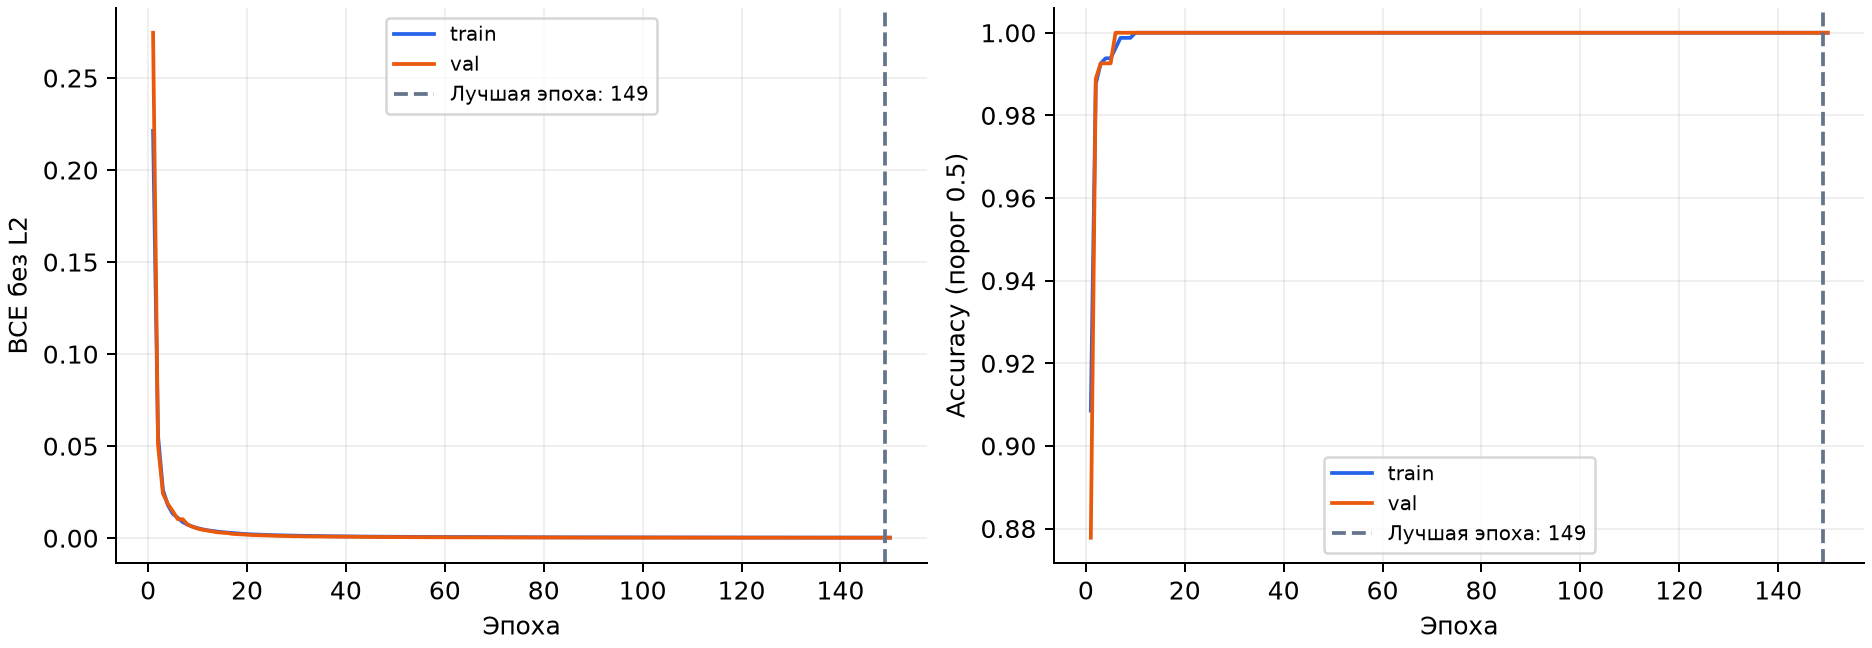

,epoch,loss,val_loss,accuracy,val_accuracy,objective
0,1,0.221315,0.274572,0.908529,0.877778,0.225235
9,10,0.005453,0.005187,1.000000,1.000000,0.010053
49,50,0.000745,0.000573,1.000000,1.000000,0.005536
99,100,0.000385,0.000292,1.000000,1.000000,0.005063
148,149,0.000299,0.000224,1.000000,1.000000,0.004808
149,150,0.000298,0.000225,1.000000,1.000000,0.004804


In [7]:
display(Image(filename=str(ROOT / 'artifacts/learning_curves.png')))
display(history.iloc[[0,9,49,99,148,149]])

## 7. Порог классификации
Решающее правило $\hat y=1[\hat p\ge\tau]$ используется при оценке,
а не при обучении. Выбираем максимум F1 **только на val**.
Проверяем середины между уникальными вероятностями и 0.5; при равном F1
берём ближайший к 0.5 порог, затем меньший. Здесь максимум F1=1 достижим
при 0.5, поэтому сохраняем $\tau=0.5$.

In [8]:
trained, saved_scaler, tau = MLP.load(ROOT / 'artifacts/model.npz')
p_val = trained.predict_proba(saved_scaler.transform(x[split['val']]))
selected, sweep = select_threshold(y[split['val']], p_val)
assert selected == tau
display(sweep[sweep.f1 == sweep.f1.max()])
print('Выбранный порог:', tau)
print('Границы идеального разделения val:', p_val[y[split['val']]==0].max(),
      p_val[y[split['val']]==1].min())

,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,tn,fp,fn,tp
148,0.500000,1.0,1.0,1.0,1.0,1.0,1.0,148,0,0,122
149,0.501646,1.0,1.0,1.0,1.0,1.0,1.0,148,0,0,122


Выбранный порог: 0.5
Границы идеального разделения val: 0.009805794738720812 0.9934856856594176


## 8. Независимая оценка test
Accuracy=(TP+TN)/N; Precision=TP/(TP+FP); Recall=TP/(TP+FN);
F1=2TP/(2TP+FP+FN). ROC-AUC не зависит от единственного порога.
Для PR используем **Average Precision** (ступенчатая сумма precision по
приращениям recall), а не трапециевидную площадь PR.

,loss,accuracy,precision,recall,f1,roc_auc,average_precision
train,0.000299,1.0,1.0,1.0,1.0,1.0,1.0
val,0.000224,1.0,1.0,1.0,1.0,1.0,1.0
test,0.000446,1.0,1.0,1.0,1.0,1.0,1.0


,Прогноз 0,Прогноз 1
Истинный 0,147,0
Истинный 1,0,122


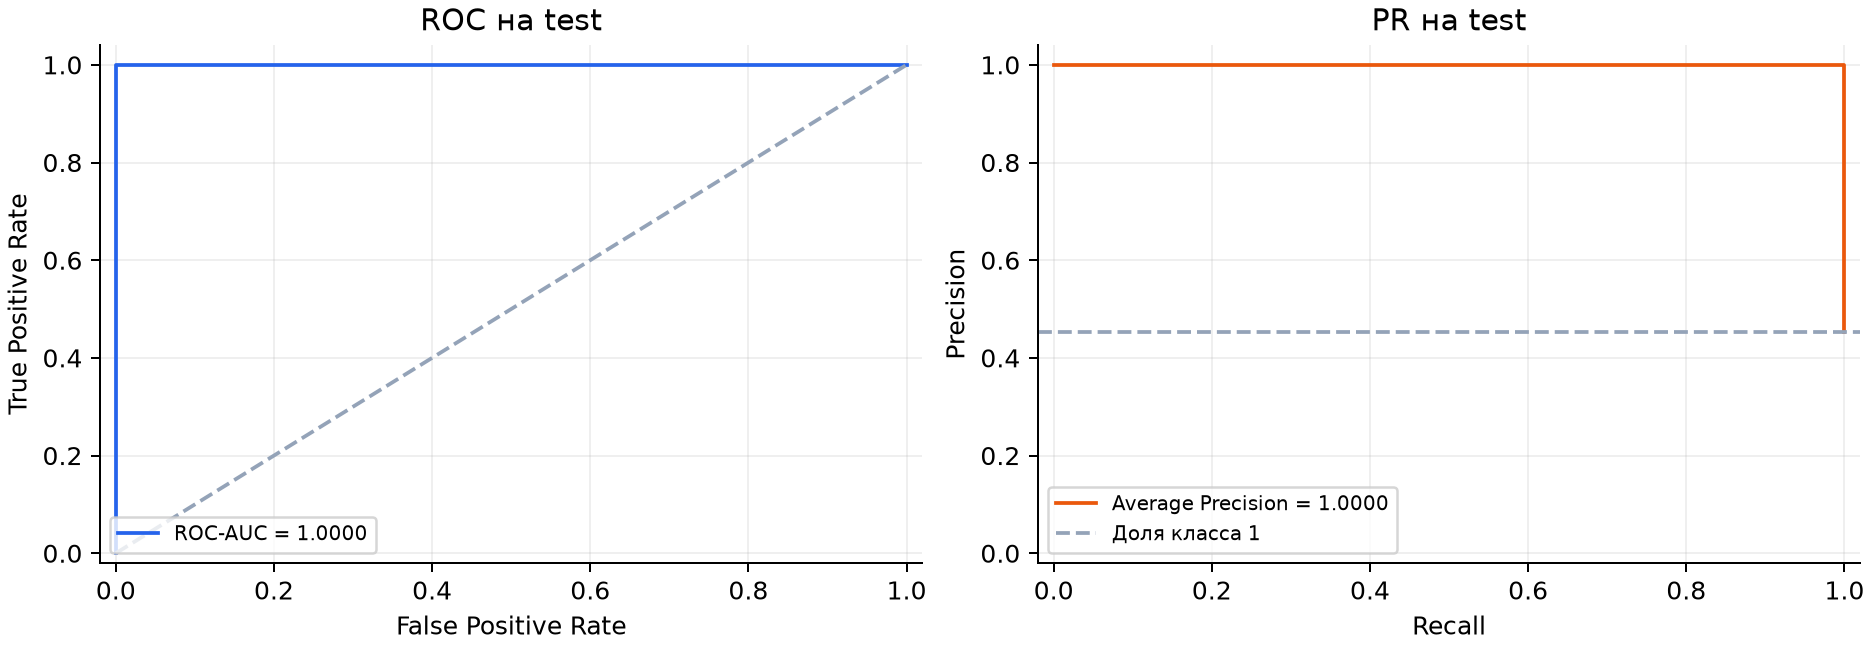

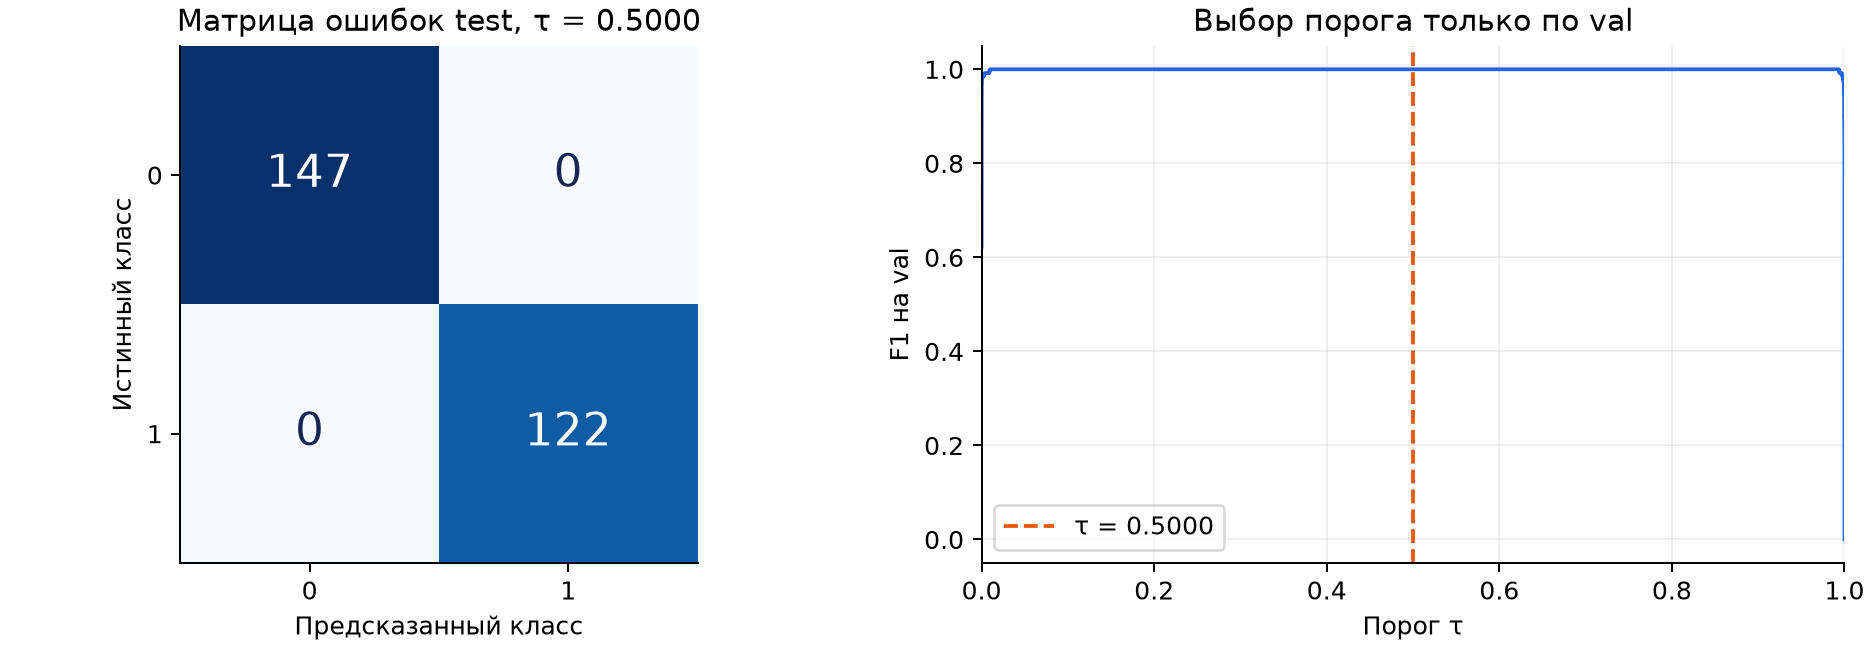

In [9]:
summary = pd.DataFrame(result['metrics']).T
display(summary[['loss','accuracy','precision','recall','f1','roc_auc','average_precision']])
test = result['metrics']['test']
display(pd.DataFrame([[test['tn'],test['fp']],[test['fn'],test['tp']]],
                     index=['Истинный 0','Истинный 1'], columns=['Прогноз 0','Прогноз 1']))
display(Image(filename=str(ROOT / 'artifacts/roc_pr.png')))
display(Image(filename=str(ROOT / 'artifacts/confusion_threshold.png')))

## 9. Сохранение модели и воспроизводимость
model.npz содержит W, b, архитектуру, L2, параметры стандартизации и порог.
test_predictions.csv содержит вероятности и прогнозы с исходными индексами.
history.csv, split.csv и results.json позволяют проверить эксперимент.
sklearn используется исключительно в независимых тестах метрик, а не в модели.

In [10]:
predictions = pd.read_csv(ROOT / 'artifacts/test_predictions.csv')
raw = np.loadtxt(ROOT / 'data/data_banknote_authentication.txt', delimiter=',')
restored_p = trained.predict_proba(saved_scaler.transform(raw[predictions.source_row, :-1]))
np.testing.assert_allclose(restored_p, predictions.probability, atol=1e-14)
assert len(predictions) == 269
assert test['accuracy'] == 1.0
print('OK: сохранённая модель воспроизводит все прогнозы test')
print('SHA-256 исходного датасета:', result['sha256'])
display(pd.Series(result['environment'], name='Окружение'))

OK: сохранённая модель воспроизводит все прогнозы test
SHA-256 исходного датасета: d0539aaed2139ba7a587b3e34fb345ce503ff7d5d33dbf9912d8e195ce425cb9


python        3.13.2
numpy          2.5.1
pandas         3.0.6
matplotlib    3.11.0
device           CPU
Name: Окружение, dtype: str

## 10. Вывод
MLP и backpropagation реализованы вручную. После удаления 24 дубликатов данные
разделены на 809/270/269 объектов; стандартизация обучена только на train.
Обучение завершилось по лимиту 150 эпох; восстановлена лучшая эпоха 149.
При пороге 0.5 на test правильно классифицированы 269 из 269 объектов:
Accuracy=F1=ROC-AUC=Average Precision=1.0, BCE≈0.000446.

Это результат одного воспроизводимого разбиения небольшого датасета.
Он не гарантирует отсутствие ошибок на новых источниках данных. По кривым
не обнаружено ухудшения val, но по одному разбиению нельзя доказать
полное отсутствие переобучения. Для более устойчивой оценки можно повторить
эксперимент с другими seed или использовать кросс-валидацию.

Материалы: методичка «Лабораторная работа 4 - самописный MLP на CPU»,
«Протокол обучения MLP с сохранением истории (CPU)», «Логирование истории
обучения MLP», материалы по backpropagation и справочник метрик из задания.
Источник данных: [UCI Banknote Authentication](https://doi.org/10.24432/C55P57).